In [14]:
import os
import sys

from google.colab import drive
drive.mount('/content/drive')

sys.path.insert(0, '/content/drive/MyDrive/LLM-Groupe-S/Model')

from Prep import ProjectSetup

setup = ProjectSetup()
setup.setup()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive monté
Mise à jour du repo...
 Repo à jour
 Dossiers créés
 Path mis à jour

 Projet : /content/drive/MyDrive/LLM-Groupe-S
 Models : /content/drive/MyDrive/LLM-Groupe-S/models
 Data   : /content/drive/MyDrive/LLM-Groupe-S/data
 Path   : /root/.ipython


In [6]:
sys.path.insert(0, '/content/drive/MyDrive/LLM-Groupe-S/Model')

from Prep import ProjectSetup

setup = ProjectSetup()
setup.setup()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive monté
Mise à jour du repo...
 Repo à jour
 Dossiers créés
 Path mis à jour

 Projet : /content/drive/MyDrive/LLM-Groupe-S
 Models : /content/drive/MyDrive/LLM-Groupe-S/models
 Data   : /content/drive/MyDrive/LLM-Groupe-S/data
 Path   : /root/.ipython


In [11]:
from prepData import PrepareData

data = PrepareData(sequence_length=20, vocab_size=5000)

alice_path = os.path.join(setup.data_dir, "alice.txt")

if os.path.exists(alice_path):
    print("Alice déjà présent sur le Drive")
    text = data.load_from_file(alice_path)
else:
    print(" Téléchargement d'Alice...")
    text = data.load_from_url(
        url          = "https://www.gutenberg.org/files/11/11-0.txt",
        start_marker = "CHAPTER I.",
        end_marker   = "End of Project Gutenberg"
    )
    data.save_text(text, alice_path)

train_ds, val_ds = data.build(text)

Alice déjà présent sur le Drive
 Vocabulaire   : 3058 mots
 Séquences     : 27723
 X shape       : (27723, 20)
y shape       : (27723, 20)
Batches train : 781
 Batches val   : 86


In [15]:
from smallGPT import SmallGPT
from trainer import Trainer

sequence_length = 20
embed_dim = 64
num_heads = 4
ff_dim = 128
num_layers = 2

model = SmallGPT(
    sequence_length = sequence_length,
    vocab_size  = data.vocab_size,
    embed_dim  = embed_dim,
    num_heads = num_heads,
    ff_dim  = ff_dim,
    num_layers = num_layers
)
model.compile(
    optimizer = "adam",
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)


In [16]:
trainer = Trainer(model, setup.model_path, epochs=60, patience=5)

if os.path.exists(setup.model_path):
    print(" reprise de l'entraînement")
    model = trainer.load()
else:
    print(" entraînement ")

history = trainer.train(train_ds, val_ds)

 entraînement 
Epoch 1/60
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1353 - loss: 5.4649
Epoch 1: val_loss improved from None to 3.95492, saving model to /content/drive/MyDrive/LLM-Groupe-S/models/best_smallgpt.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LLM-Groupe-S/models/best_smallgpt.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 96s 114ms/step - accuracy: 0.2160 - loss: 4.5135 - val_accuracy: 0.2516 - val_loss: 3.9549
Epoch 2/60
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3111 - loss: 3.3088
Epoch 2: val_loss improved from 3.95492 to 3.01080, saving model to /content/drive/MyDrive/LLM-Groupe-S/models/best_smallgpt.keras

Epoch 2: finished saving model to /content/drive/MyDrive/LLM-Groupe-S/models/best_smallgpt.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.3463 - loss: 2.9977 - val_accuracy: 0.3241 - val_loss: 3.0108
Epoch 3/60
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3897 - loss: 2.6283
Epoch 3: val_loss improved

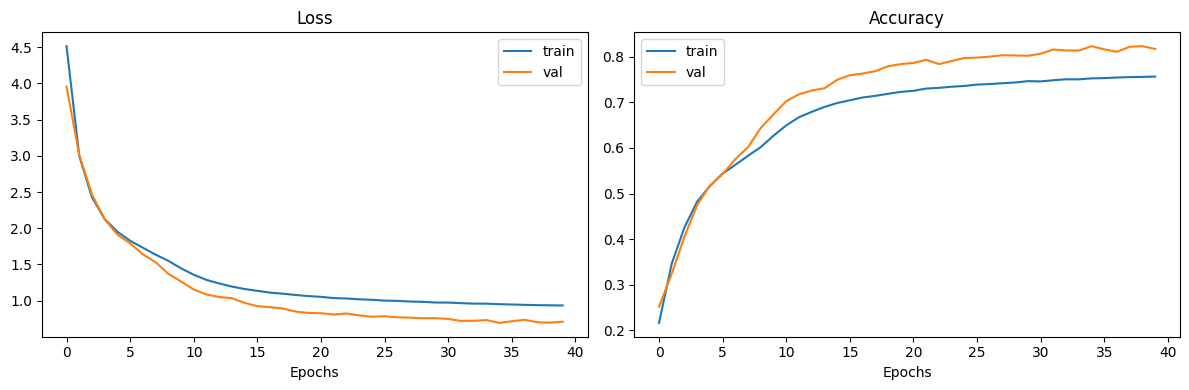

In [17]:
import matplotlib.pyplot as plt

def afficher_courbes(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'],     label='train')
    ax1.plot(history.history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.legend()

    ax2.plot(history.history['accuracy'],     label='train')
    ax2.plot(history.history['val_accuracy'], label='val')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.legend()

    plt.tight_layout()
    plt.show()

afficher_courbes(history)


In [20]:
import numpy as np

def generer(model, prompt, tokenizer, sequence_length,
            num_mots=11, temperature=0.8, top_k=10):

    index_to_word = {v: k for k, v in tokenizer.word_index.items()}
    tokens        = tokenizer.texts_to_sequences([prompt])[0]
    generated     = tokens[:]

    for _ in range(num_mots):
        seq        = np.array([generated[-sequence_length:]])
        prediction = model.predict(seq, verbose=0)[0, -1]

        # Température
        prediction = np.log(prediction + 1e-8) / temperature
        prediction = np.exp(prediction) / np.sum(np.exp(prediction))

        # Top-K sampling
        top_k_indices = np.argsort(prediction)[-top_k:]
        top_k_probs   = prediction[top_k_indices]
        top_k_probs  /= np.sum(top_k_probs)

        next_token = np.random.choice(top_k_indices, p=top_k_probs)

        # Ignorer <OOV>
        if next_token == tokenizer.word_index.get("<OOV>", 0):
            continue

        generated.append(next_token)

    # Décoder
    mots = [index_to_word.get(i, "?") for i in generated]
    return " ".join(mots)

# Test
print(generer(model, "alice was", data.tokenizer, sequence_length))
print(generer(model, "the rabbit", data.tokenizer, sequence_length))

alice was very glad to find herself still it had kept fanning herself
the rabbit went on muttering over the verses to himself “‘ we know
